In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier


In [5]:
url = "BD_limpio.csv"
df = pd.read_csv(url)
df

,Unnamed: 0,Titulo,Promedio de voto,Conteo de voto,status,Fecha de lanzamiento,Ingresos,Duracion,Adultos,Presupuesto,...,Popularidad,Genero,Productora,Pais,Idiomas,PL,año,mes,dia,díanombre
0,0,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,160000000,...,83.952,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",2010.0,7.0,15.0,Thursday
1,1,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,165000000,...,140.241,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",2014.0,11.0,5.0,Wednesday
2,2,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,185000000,...,130.643,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",2008.0,7.0,16.0,Wednesday
3,3,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,237000000,...,79.932,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",2009.0,12.0,15.0,Tuesday
4,4,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,220000000,...,98.082,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",2012.0,4.0,25.0,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126922,1121401,Preston's Gone,0.000,0,Released,2019-06-02,0,11,False,0,...,0.600,Documentary,Louisiana Public Broadcasting,United States of America,English,"police brutality, war veteran, mental health, ...",2019.0,6.0,2.0,Sunday
126923,1121429,After the Ballot,0.000,0,Released,2008-01-01,0,89,False,0,...,0.600,Documentary,ONF | NFB,Canada,French,"canada, politics, quebec",2008.0,1.0,1.0,Tuesday
126924,1121513,The Pig from Turkey,0.000,0,Released,2020-01-26,0,14,False,0,...,0.603,Drama,Madbunny Productions,Sweden,Swedish,"identity, racism, short film",2020.0,1.0,26.0,Sunday
126925,1121698,Tooth 4 Tooth,0.000,0,Released,2020-05-20,0,14,False,3000,...,0.600,Horror,One Manner Productions,Australia,English,"vampire, gay interest, blood lust, lgbt, short...",2020.0,5.0,20.0,Wednesday


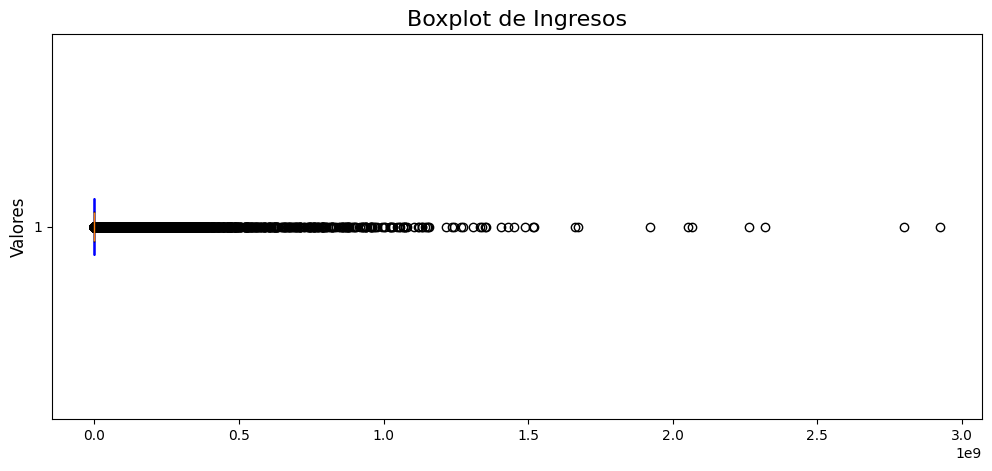

In [6]:
# Crear el boxplot
plt.figure(figsize=(12, 5))
plt.boxplot(df['Ingresos'], patch_artist=True, notch=True, boxprops=dict(facecolor='lightblue', color='blue'), vert=False)

# Personalizar el gráfico
plt.title('Boxplot de Ingresos', fontsize=16)
plt.ylabel('Valores', fontsize=12)

# Mostrar el gráfico
plt.show()

In [9]:
# Seleccionar solo las columnas numéricas
df_numeric = df[['Promedio de voto', 'Conteo de voto', 'Ingresos', 'Duracion', 'Presupuesto', 'Popularidad', "año", "mes", "dia"]]
# Calcular la matriz de correlación
correlation_matrix = df_numeric.corr()
correlation_matrix

,Promedio de voto,Conteo de voto,Ingresos,Duracion,Presupuesto,Popularidad,año,mes,dia
Promedio de voto,1.000000,0.125264,0.083977,0.216846,0.093414,0.107523,0.057752,0.046495,0.051083
Conteo de voto,0.125264,1.000000,0.777309,0.126993,0.661782,0.260248,0.076162,0.026836,0.022923
Ingresos,0.083977,0.777309,1.000000,0.104921,0.756800,0.268631,0.061224,0.018770,0.018368
Duracion,0.216846,0.126993,0.104921,1.000000,0.132675,0.098599,0.138660,0.061087,0.063290
Presupuesto,0.093414,0.661782,0.756800,0.132675,1.000000,0.292980,0.088790,0.024839,0.021078
Popularidad,0.107523,0.260248,0.268631,0.098599,0.292980,1.000000,0.070851,0.020204,0.021430
año,0.057752,0.076162,0.061224,0.138660,0.088790,0.070851,1.000000,0.037795,0.038630
mes,0.046495,0.026836,0.018770,0.061087,0.024839,0.020204,0.037795,1.000000,0.122021
dia,0.051083,0.022923,0.018368,0.063290,0.021078,0.021430,0.038630,0.122021,1.000000


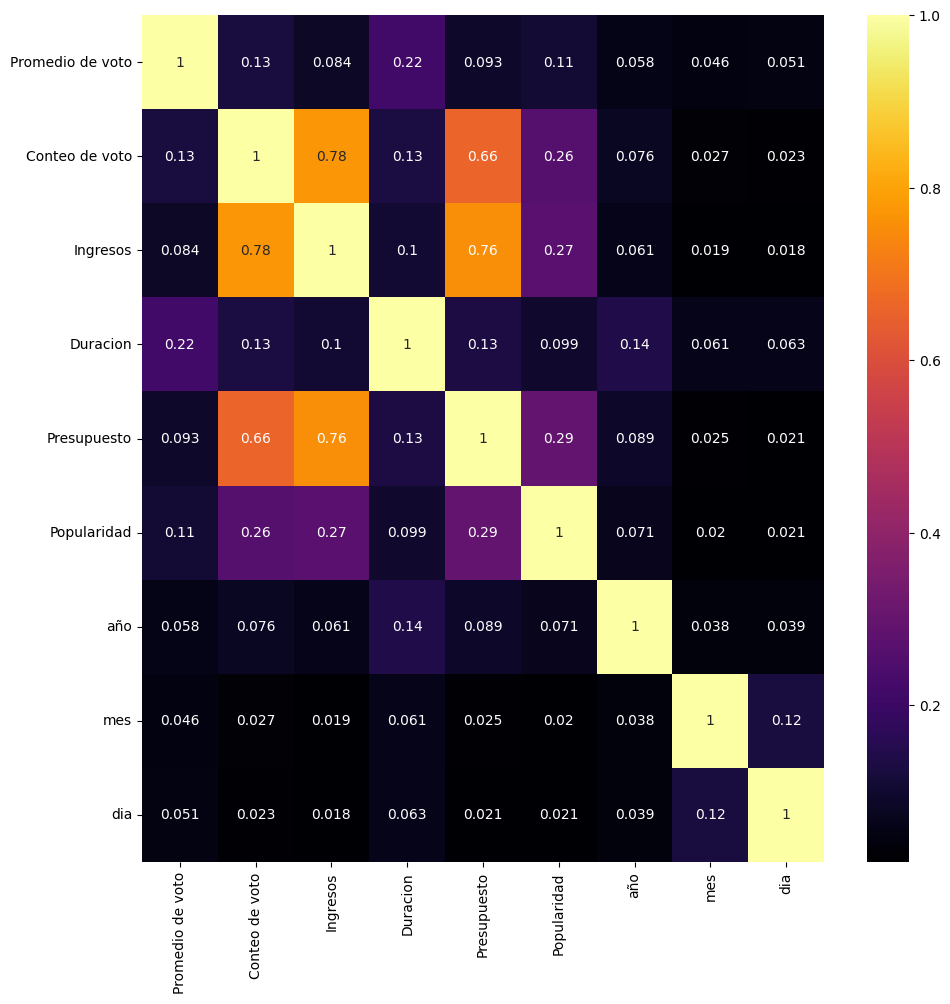

In [10]:
# Gráfico de calor
plt.figure (figsize = (11,11))
sns.heatmap(correlation_matrix, annot=True, cmap='inferno')
plt.show()

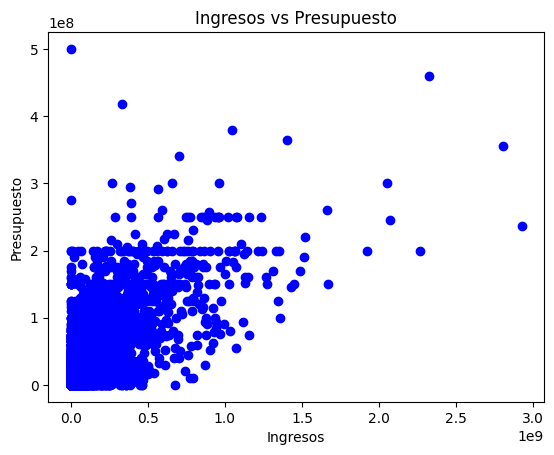

In [11]:
plt.scatter(df['Ingresos'], df['Presupuesto'], color='blue')
plt.title('Ingresos vs Presupuesto')
plt.xlabel('Ingresos')
plt.ylabel('Presupuesto')
plt.show()

In [12]:
# Calcular el coeficiente de correlación de Pearson
correlacion_pearson = df['Ingresos'].corr(df['Presupuesto'], method='pearson')

print(f"Coeficiente de correlación de Pearson: {correlacion_pearson}")

Coeficiente de correlación de Pearson: 0.7568001340926959


In [13]:
X = df[['Ingresos']]
y = df[['Presupuesto']]

# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
X_train

,Ingresos
13247,0
2713,193921372
81681,0
68770,0
102103,0
...,...
119879,0
103694,0
860,77912251
15795,0


In [15]:
y_train

,Presupuesto
13247,0
2713,68000000
81681,0
68770,0
102103,0
...,...
119879,0
103694,0
860,20000000
15795,0


In [16]:
X_test

,Ingresos
7448,962689
50795,0
17735,0
111067,0
114983,0
...,...
65023,0
76677,0
118405,0
40110,0


In [17]:
y_test

,Presupuesto
7448,0
50795,0
17735,0
111067,0
114983,0
...,...
65023,0
76677,0
118405,0
40110,0


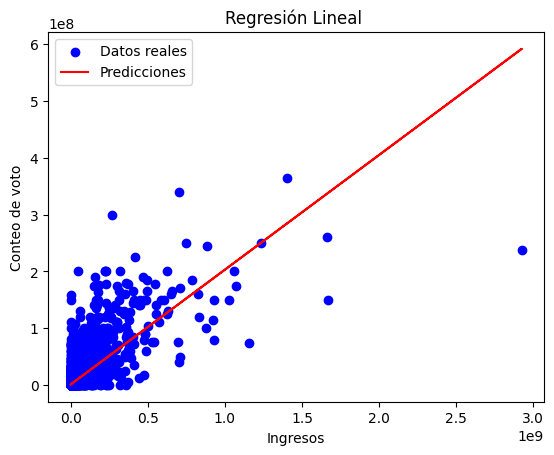

In [18]:
# Creación del modelo de regresión lineal
modelo = LinearRegression()

# Entrenar el modelo
modelo.fit(X_train, y_train)

# Realizar predicciones
y_pred = modelo.predict(X_test)

# Visualizar los resultados
plt.scatter(X_test, y_test, color='blue', label='Datos reales')
plt.plot(X_test, y_pred, color='red', label='Predicciones')
plt.title('Regresión Lineal ')
plt.xlabel('Ingresos')
plt.ylabel('Conteo de voto')
plt.legend()
plt.show()


c:\Users\yarf2\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


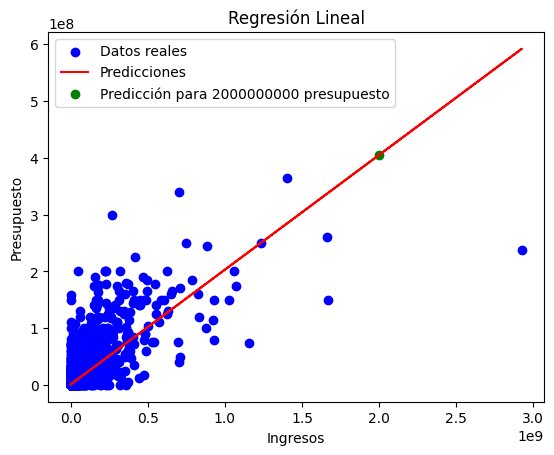

La predicción para 2000000000 de presupuesto es: [4.05029634e+08]


In [19]:
# Visualizar los resultados del conjunto de prueba
plt.scatter(X_test, y_test, color='blue', label='Datos reales')
plt.plot(X_test, y_pred, color='red', label='Predicciones')
plt.title('Regresión Lineal')
plt.xlabel('Ingresos')
plt.ylabel('Presupuesto')
plt.legend()

# Predicción para un valor específico de X
x_nuevo = [[2000000000]]  # Cambia este valor a las horas de estudio que deseas predecir
y_nuevo = modelo.predict(x_nuevo)

# Mostrar la predicción en la gráfica
plt.scatter(x_nuevo, y_nuevo, color='green', label=f'Predicción para {x_nuevo[0][0]} presupuesto')
plt.legend()

plt.show()

# Imprimir el valor predicho
print(f'La predicción para {x_nuevo[0][0]} de presupuesto es: {y_nuevo[0]}')

In [20]:
fig = px.box(df, y='Presupuesto', title='Deteccion de datos atipicos')
fig.update_layout(width=300, height=500)
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed